In [7]:
import fast_tsne
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 22})

# ~Using t-SNE to plot the dataset~
t-SNE is way better than PCA in preserving local structures.
However, *this test was aborted due to its complexity*. On my i7-10750H it would require about 1h!

In [12]:
train_x = pd.read_csv('../dataset/0-original/X.csv').drop('id', axis=1)
train_y = pd.read_csv('../dataset/0-original/y.csv')['faulty'].values

train_mean, train_std = train_x.mean(), train_x.std()
train_x = (train_x - train_mean) / train_std
base_features = train_x.columns

valid_x = pd.read_csv('../dataset/0-original/X_validation.csv').drop('id', axis=1)
valid_x = (valid_x - train_mean) / train_std
test_x = pd.read_csv('../dataset/0-original/X_test.csv').drop('id', axis=1)
test_x = (test_x - train_mean) / train_std
valid_test_x = pd.concat([valid_x, test_x], ignore_index=True)

In [9]:
def plot_3d_tsne(data, labels, features=base_features, scale=0.5, ax=None, c=None, alpha=0.04, azim=180 + 55,
                 only_faulty=False, perplexity=30, random_state=42):
    tsne = TSNE(n_components=3, perplexity=perplexity, n_jobs=-1, random_state=random_state)
    tsne_results = tsne.fit_transform(data[features].values)
    data['TSNE1'], data['TSNE2'], data['TSNE3'] = tsne_results[:, 0], tsne_results[:, 1], tsne_results[:, 2]

    if ax is None:
        fig = plt.figure(figsize=(20 * scale, 20 * scale))
        ax = fig.add_subplot(111, projection='3d')
        ax.view_init(elev=25, azim=azim)
        plt.legend(loc="upper right")
        plt.grid(True)

    if c is None:
        c = {0: 'g', 1: 'r'}
    s = 0.5 * 750_000 / len(data)

    for label in [0, 1] if not only_faulty else [1]:
        ax.scatter(
            data[labels == label]['TSNE1'],
            data[labels == label]['TSNE2'],
            data[labels == label]['TSNE3'],
            c=c[label],
            label={0: 'Healthy', 1: 'Faulty'}[label], alpha=alpha, s=s
        )
    return ax

C:\Users\MrPio\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\MrPio\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\MrPio\AppData\Local\Temp\ipykernel_32740\2055099171.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['TSNE1'], data['TSNE2'], data['TSNE3'] = tsne_results[:, 0], tsne_results[:, 1], tsne_results[:, 2]
C:\Users\MrPio\AppData\Local\Temp\ipykernel_32740\2055099171.py:5: SettingWithCopyWarning: 
A value is trying t

<Axes3D: >

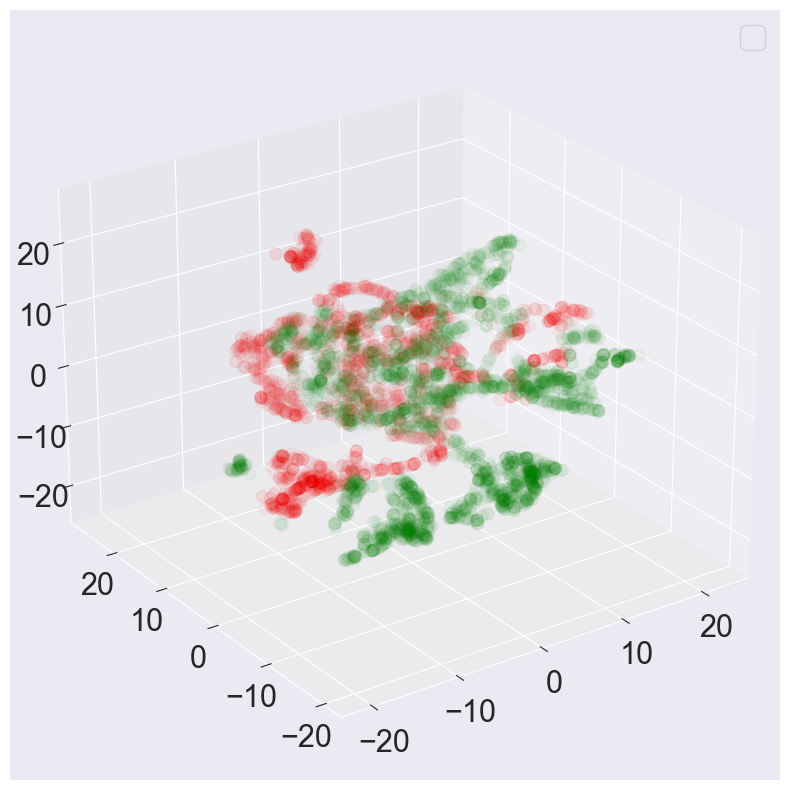

In [11]:
plot_3d_tsne(train_x[:5_000], train_y[:5_000])